## Nội dung

- Feature engineering
- Phân cụm: KMeans, DBSCAN
- Kết hợp phân cụm và phân tích mô tả
- Kết hợp PCA và phân cụm
- Tập dữ liệu:
   1. Customer Personality Analysis (nguồn: https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis)
   2. Taxi geolocation (nguồn: https://www.coursera.org/projects/clustering-geolocation-data-intelligently-python)

#### Cài đặt thư viện

In [34]:
!pip install folium
!pip install kneed
!pip install yellowbrick
!pip install kneed

### A. Customer Personality Analysis

#### A1. Đọc dữ liệu

In [2]:
import numpy as np
import pandas as pd

In [3]:
pd.set_option('display.max_columns', None)
customer_data = pd.read_csv('data/marketing_campaign.csv',
                           delimiter='\t', index_col='ID')
customer_data.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


#### A2. Làm sạch
- Làm sạch dữ liệu.
- Trích xuất đặc trưng (đọc thêm: https://machinelearningcoban.com/general/2017/02/06/featureengineering/)

In [4]:
customer_data.info()

<class 'pandas.DataFrame'>
Index: 2240 entries, 5524 to 9405
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year_Birth           2240 non-null   int64  
 1   Education            2240 non-null   str    
 2   Marital_Status       2240 non-null   str    
 3   Income               2216 non-null   float64
 4   Kidhome              2240 non-null   int64  
 5   Teenhome             2240 non-null   int64  
 6   Dt_Customer          2240 non-null   str    
 7   Recency              2240 non-null   int64  
 8   MntWines             2240 non-null   int64  
 9   MntFruits            2240 non-null   int64  
 10  MntMeatProducts      2240 non-null   int64  
 11  MntFishProducts      2240 non-null   int64  
 12  MntSweetProducts     2240 non-null   int64  
 13  MntGoldProds         2240 non-null   int64  
 14  NumDealsPurchases    2240 non-null   int64  
 15  NumWebPurchases      2240 non-null   int64  
 16  N

Dữ liệu khá sạch và chỉ có 1 số lượng nhỏ income bị thiếu dữ liệu, có thể xử lý bằng cách thêm vào mean. Mã hoá 1 số đặc trưng kiểu loại.

In [5]:
# TODO, Xử lý dữ liệu khuyết cho Income bằng cách thêm mean
income_mean = customer_data['Income'].mean()
customer_data['Income'] = customer_data['Income'].fillna(income_mean)
print('Số Income còn thiếu:', customer_data['Income'].isna().sum())

Số Income còn thiếu: 0


#### A3. Feature engineering

In [6]:
import datetime

Đầu tiên là dữ liệu liên quan ngày tháng.

- `Year_Birth` không phải là đặc trưng lý tưởng cho bài toán này, ta sẽ chuyển nó sang thành tuổi `Age` (tính từ hiện tại)

In [7]:
# Trích xuất tuổi từ đặc trưng năm sinh
# hint: 2022 - x
customer_data['Age'] = 2022 - customer_data['Year_Birth']
customer_data[['Year_Birth', 'Age']].head()

,Year_Birth,Age
ID,,
5524,1957,65
2174,1954,68
4141,1965,57
6182,1984,38
5324,1981,41


- `Days_Since_Customer`, tương tự như `Year_Birth`, nên được chuyển thành số ngày đã tham gia `Enroll_days`.

In [12]:
# Đặc trưng 'Days_Since_Customer' ~ ngày tham gia, biến đổi thành số lượng ngày đã tham gia
customer_data['Dt_Customer'] = pd.to_datetime(customer_data['Dt_Customer'], dayfirst=True, errors='coerce')
now = pd.Timestamp.now().normalize()
customer_data['Enroll_days'] = (now - customer_data['Dt_Customer']).dt.days
customer_data[['Dt_Customer', 'Enroll_days']].head()


,Dt_Customer,Enroll_days
ID,,
5524,2012-09-04,5145
2174,2014-03-08,4595
4141,2013-08-21,4794
6182,2014-02-10,4621
5324,2014-01-19,4643


- Các đặc trưng `Marital_Status`, `Kidhome`, `Teenhome` có thể được gom lại 1 thuộc tính duy nhất --> cô động hơn

In [ ]:
marital_map = {'Absurd':1,
               'Alone':1,
               'YOLO':1,'Single':1,
               'Married':2,'Together':2,
               'Widow':1,'Divorced':1}
customer_data['Marital_Status'] = customer_data['Marital_Status'].map(marital_map).fillna(1).astype(int)
customer_data['Fam_Size'] = customer_data['Marital_Status'] + customer_data['Kidhome'] + customer_data['Teenhome']
customer_data[['Marital_Status','Kidhome','Teenhome','Fam_Size']].head()


,Marital_Status,Kidhome,Teenhome,Fam_Size
ID,,,,
5524,1,0,0,1
2174,1,1,1,3
4141,2,0,0,2
6182,2,1,0,3
5324,2,1,0,3


- Gom các đặc trưng `AcceptedCmpX` thành 1 đặc trưng `Num_Accepted` (tổng)
- Làm tương tự cho các đặc trưng MntX, gom thành đặc trưng `MntTotal`

In [16]:
# Num_Accepted = AcceptedCmp1 + AcceptedCmp2 + ...

accepted_cols = ['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5']
customer_data['Num_Accepted'] = customer_data[accepted_cols].sum(axis=1)
customer_data[['Num_Accepted'] + accepted_cols].head()

,Num_Accepted,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5
ID,,,,,,
5524,0,0,0,0,0,0
2174,0,0,0,0,0,0
4141,0,0,0,0,0,0
6182,0,0,0,0,0,0
5324,0,0,0,0,0,0


In [17]:
# Có thể gộp các đặc trưng MntXXX thành 1 thuộc tính duy nhất (tính tổng)
mnt_cols = ['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds']
customer_data['MntTotal'] = customer_data[mnt_cols].sum(axis=1)
customer_data[['MntTotal'] + mnt_cols].head()

,MntTotal,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
ID,,,,,,,
5524,1617,635,88,546,172,88,88
2174,27,11,1,6,2,1,6
4141,776,426,49,127,111,21,42
6182,53,11,4,20,10,3,5
5324,422,173,43,118,46,27,15


#### A4. Phân tích EDA

In [18]:
customer_data.describe()

,Year_Birth,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Enroll_days,Fam_Size,Num_Accepted,MntTotal
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,1968.805804,1.644643,52247.251354,0.444196,0.506250,2013-07-10 10:01:42.857142,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107,53.194196,4835.582143,2.595089,0.297768,605.798214
min,1893.000000,1.000000,1730.000000,0.000000,0.000000,2012-07-30 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,26.000000,4482.000000,1.000000,0.000000,5.000000
25%,1959.000000,1.000000,35538.750000,0.000000,0.000000,2013-01-16 00:00:00,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,45.000000,4662.750000,2.000000,0.000000,68.750000
50%,1970.000000,2.000000,51741.500000,0.000000,0.000000,2013-07-08 12:00:00,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,52.000000,4837.500000,3.000000,0.000000,396.000000
75%,1977.000000,2.000000,68289.750000,1.000000,1.000000,2013-12-30 06:00:00,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,63.000000,5011.000000,3.000000,0.000000,1045.500000
max,1996.000000,2.000000,666666.000000,2.000000,2.000000,2014-06-29 00:00:00,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000,129.000000,5181.000000,5.000000,4.000000,2525.000000
std,11.984069,0.478728,25037.797168,0.538398,0.544538,NaN,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274,11.984069,202.122512,0.906959,0.678381,602.249288


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

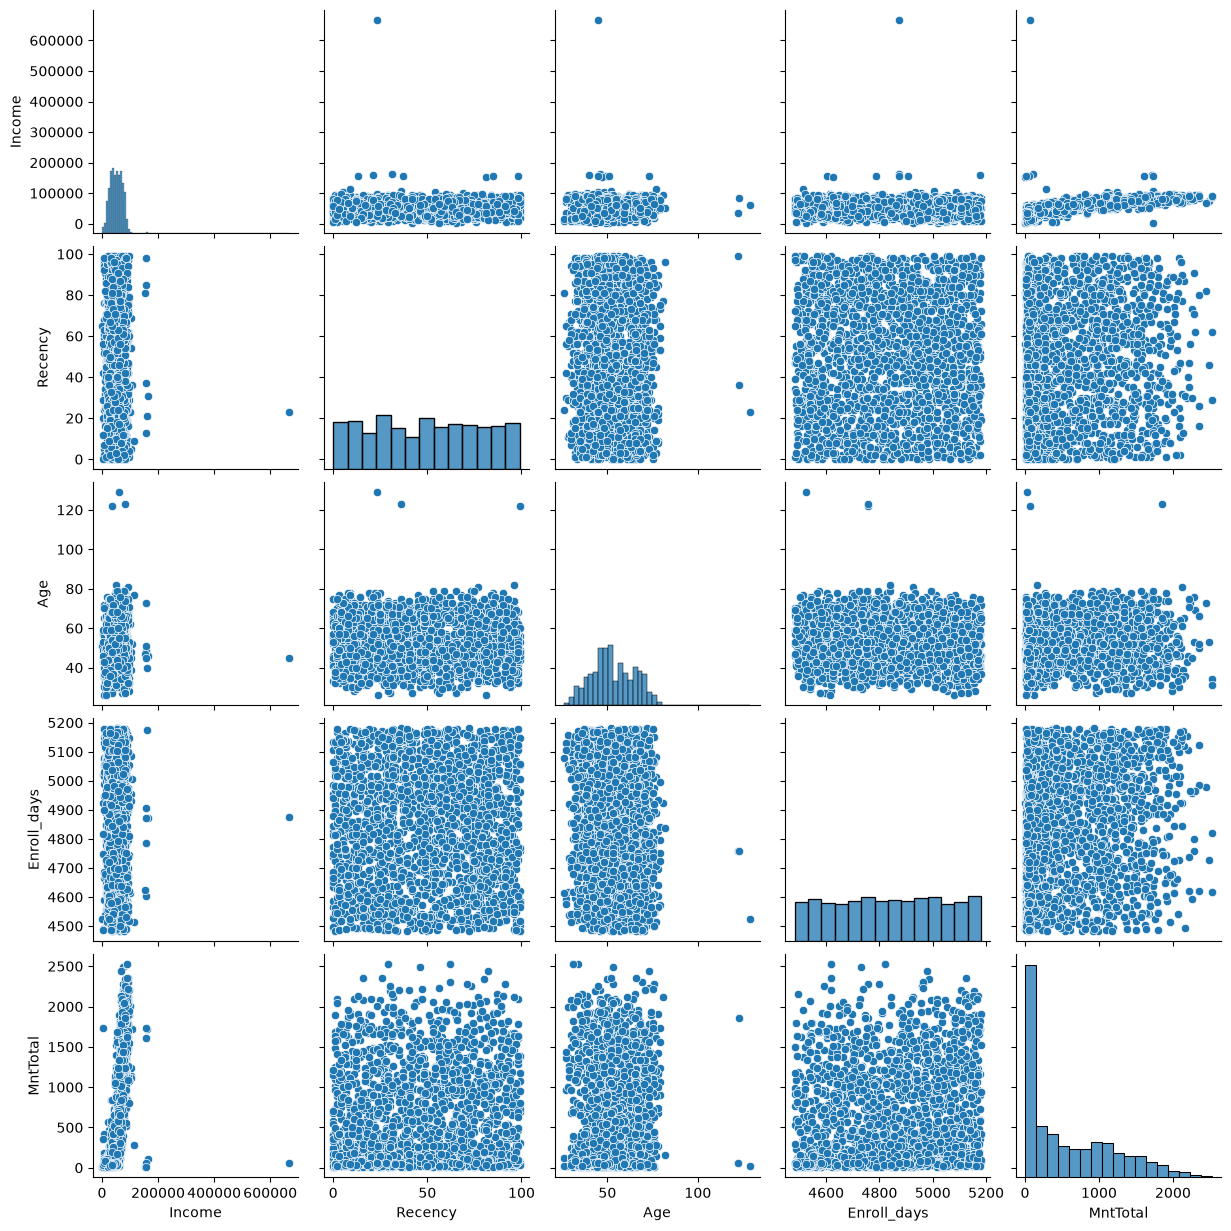

In [20]:
plot_cols = ['Income', 'Recency', 'Age', 'Enroll_days', 'MntTotal']
# TODO - vẽ pair plot
plot_cols = ['Income','Recency','Age','Enroll_days','MntTotal']
sns.pairplot(customer_data[plot_cols].dropna(), diag_kind='hist')
plt.show()

In [21]:
# TODO - xử lý nhiễu (nếu có)
Q1 = customer_data[plot_cols].quantile(0.25)
Q3 = customer_data[plot_cols].quantile(0.75)
IQR = Q3 - Q1
outlier_mask = ((customer_data[plot_cols] < (Q1 - 1.5*IQR)) | (customer_data[plot_cols] > (Q3 + 1.5*IQR))).any(axis=1)
print('Số dòng trước:', len(customer_data))
print('Số dòng ngoại lệ:', int(outlier_mask.sum()))
customer_data = customer_data.loc[~outlier_mask].copy()
print('Số dòng sau:', len(customer_data))

Số dòng trước: 2240
Số dòng ngoại lệ: 14
Số dòng sau: 2226


In [22]:
import copy
df = customer_data.copy()

# Drop các cột không quan trọng
df.drop([
    'Dt_Customer', 'Year_Birth',
    'Kidhome', 'Teenhome', 'Marital_Status',
    'Z_CostContact', 'Z_Revenue',
    'MntWines', 'MntFruits', 'MntMeatProducts',
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
    'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
    'AcceptedCmp4','AcceptedCmp5',
    'Complain', 'Response', 'Education', 'Num_Accepted'
], axis=1, inplace=True)

#### A5. Tiền xử lý

**Mã hoá đặc trưng kiểu loại**

In [23]:
# TODO
cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()
if cat_cols:
    df = pd.get_dummies(df, columns=cat_cols, dtype=float)
    print('Các cột đã one-hot:', cat_cols)
else:
    print('Không còn cột kiểu loại cần mã hoá.')
print('Shape sau mã hoá:', df.shape)

Không còn cột kiểu loại cần mã hoá.
Shape sau mã hoá: (2226, 11)


**Chuẩn hoá các thuộc tính kiểu số**

In [24]:
# TODO
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df = pd.DataFrame(scaler.fit_transform(df), columns=df.columns, index=df.index)
df.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Age,Enroll_days,Fam_Size,MntTotal
ID,,,,,,,,,,,
5524,0.319038,0.306764,0.357875,1.405082,2.639583,-0.557672,0.688640,1.014839,1.528030,-1.762774,1.698128
2174,-0.254513,-0.384037,-0.169695,-1.116686,-0.584500,-1.174965,-0.140410,1.271537,-1.191595,0.443543,-0.964498
4141,0.974338,-0.798517,-0.697265,1.405082,-0.226268,1.294209,-0.554934,0.330310,-0.207585,-0.659615,0.289783
6182,-1.212442,-0.798517,-0.169695,-0.756433,-0.942731,-0.557672,0.274115,-1.295446,-1.063030,0.443543,-0.920958
5324,0.326576,1.550205,1.413016,0.324324,0.131963,0.059622,-0.140410,-1.038748,-0.954245,0.443543,-0.303028


In [25]:
df.describe() # --> Kiểm tra mean và std có gần với giá trị (0, 1)?

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Age,Enroll_days,Fam_Size,MntTotal
count,2.226000e+03,2.226000e+03,2.226000e+03,2.226000e+03,2226.000000,2.226000e+03,2.226000e+03,2.226000e+03,2.226000e+03,2.226000e+03,2.226000e+03
mean,2.872814e-17,1.037405e-17,-2.553613e-17,1.436407e-16,0.000000,1.356607e-16,-2.872814e-17,2.234411e-17,-2.072416e-15,2.266331e-16,-7.341637e-17
std,1.000225e+00,1.000225e+00,1.000225e+00,1.000225e+00,1.000225,1.000225e+00,1.000225e+00,1.000225e+00,1.000225e+00,1.000225e+00,1.000225e+00
min,-2.424127e+00,-1.696558e+00,-1.224835e+00,-1.476938e+00,-0.942731,-1.792259e+00,-2.213034e+00,-2.322240e+00,-1.750354e+00,-1.762774e+00,-1.001339e+00
25%,-7.869717e-01,-8.675972e-01,-6.972646e-01,-7.564331e-01,-0.942731,-8.663184e-01,-9.694592e-01,-6.964836e-01,-8.553500e-01,-6.596154e-01,-8.941644e-01
50%,-2.168069e-03,1.317362e-02,-1.696946e-01,-3.592814e-02,-0.226268,-2.490250e-01,2.741152e-01,-9.752077e-02,9.985063e-03,4.435430e-01,-3.465678e-01
75%,8.009086e-01,8.594044e-01,3.578755e-01,6.845768e-01,0.490195,6.769153e-01,6.886401e-01,8.437065e-01,8.654306e-01,4.435430e-01,7.343913e-01
max,3.022716e+00,1.722905e+00,6.688716e+00,8.249879e+00,9.087750,2.220149e+00,6.077463e+00,2.469463e+00,1.706042e+00,2.649860e+00,3.153362e+00


#### A6. Phân cụm KMeans

In [26]:
from sklearn.cluster import KMeans

Phương pháp Elbow: ước lượng số cụm

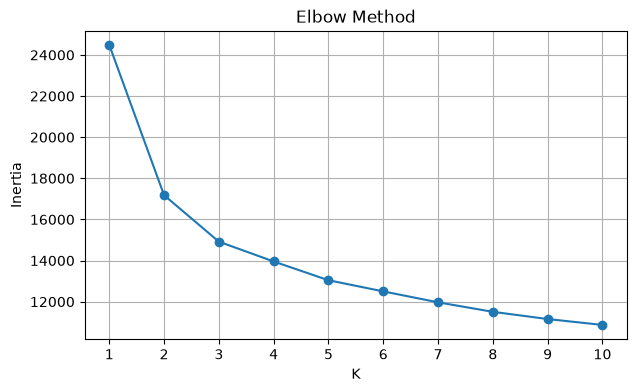

K gợi ý từ Elbow: 3


In [27]:
# TODO - vẽ biểu đồ elbow để ước lượng số cụm
from kneed import KneeLocator
ks = list(range(1,11))
inertias = []
for k in ks:
    model_k = KMeans(n_clusters=k, n_init=20, random_state=99)
    model_k.fit(df)
    inertias.append(model_k.inertia_)
plt.figure(figsize=(7,4)); plt.plot(ks,inertias,marker='o'); plt.xticks(ks); plt.xlabel('K'); plt.ylabel('Inertia'); plt.title('Elbow Method'); plt.grid(True); plt.show()
knee = KneeLocator(ks, inertias, curve='convex', direction='decreasing')
k_elbow_manual = knee.elbow
print('K gợi ý từ Elbow:', k_elbow_manual)

Sử dụng thư viện yellowbrick

In [1]:
from yellowbrick.cluster import KElbowVisualizer

ImportError: DLL load failed while importing _loss: An Application Control policy has blocked this file.

In [39]:
import sys
!{sys.executable} -m pip install --upgrade setuptools
!{sys.executable} -m pip install --upgrade scikit-learn yellowbrick kneed

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.3 MB 670.4 kB/s eta 0:00:12
   -- ------------------------------------- 0.5/8.3 MB 670.4 kB/s eta 0:00:12
   -- ------------------------------------- 0.5/8.3 MB 670.4 kB/s eta 0:00:12
   --- ------------------------------------ 0.8/8.3 MB 516.0 kB/s eta 0:00:15
   --- ------------------------------------ 0.8/8.3 MB 516.0 kB/s eta 0:00:15
   --- ------------------------------------ 0.8/8.3 MB 516.0 kB/s eta 0:00:15
   --- ------------------------------------ 0.8/8.3 MB 516.0 kB/s eta 0:00:15
   ----- ---------------------------------- 1.0/8.3 MB 430.0 kB/s eta 0:00:17
   ----- ----------------------

  You can safely remove it manually.


In [29]:
# TODO
model = KMeans(n_init=20, random_state=99)
visualizer = KElbowVisualizer(model, k=(2,10), metric='distortion', timings=False)
visualizer.fit(df)
visualizer.show()
print('K gợi ý từ Yellowbrick:', visualizer.elbow_value_)

NameError: name 'KElbowVisualizer' is not defined

**Phân cụm từ kết quả của phương pháp Elbow**

In [ ]:
# TODO

**Sử dụng PCA giảm số chiều dữ liệu --> trực quan hoá kết quả phân cụm**

In [ ]:
from sklearn.decomposition import PCA

In [ ]:
# Biến đổi dữ liệu sang không gian 2 chiều pca
# TODO

**Trực quan hoá kết quả phân cụm**

In [ ]:
def visualize_cluster_result(scores, labels):
    '''
    Args:
        scores: biến đổi pca 2d
        labels: nhãn của từng điểm dữ liệu trong scores (chính là label của kết quả phân cụm)
    '''
    # TODO
    fig1, (axes) = plt.subplots(figsize=(8,8))
    scat_1 = sns.scatterplot(
                            x=scores[:,0],
                            y=scores[:,1],
                            hue=labels, ax=axes,
                            palette='Set1', legend='full'
            )
    plt.show()

#### Phân tích kết quả phân cụm (KMeans)

In [ ]:
# Gán kết quả phân cụm vào df ban đầu ~ customer_data
kmean_df = customer_data.copy()
kmean_df['Cluster'] = kmean.labels_
kmean_df.head()

In [ ]:
def visualize_cluster_distribution(labels):
    '''
    Args:
        labels: kết quả phân cụm (danh sách nhãn)
    '''
    ulabels, count = np.unique(labels, return_counts=True)
    plt.figure(figsize=(6,4))

    colors = sns.color_palette('Set2')[0:5]
    
    labels = [f'Cluster {i+1}' for i in range(len(ulabels))]
    plt.pie(count, 
            explode=[0.05]*len(ulabels), 
            labels=labels,
            colors=colors,
            autopct='%1.1f%%',
            textprops=dict(color ="white", fontsize=10),
            counterclock=False,
            startangle=180,
            wedgeprops={"edgecolor":"gray",'linewidth': 1}
        )

    plt.axis('equal')
    plt.legend()
    plt.show()

In [ ]:
# visualize_cluster_distribution(kmean.labels_)

**Phân tích đa biến + kết quả phân cụm**

In [ ]:
# đặc trưng income và MntTotal: vẽ sns scatterplot với hue là Cluster
# TODO

In [ ]:
# đặc trưng Fam_Size và MntTotal: vẽ sns scatterplot với hue là Cluster
# TODO

**Phân tích danh mục mua hàng**

In [ ]:
# TODO

#### A7. Kết hợp PCA và phân cụm
- Biến đổi PCA với số lượng component phù hợp (giữ lại 70-80% thông tin ban đầu).
- Ước lượng số cụm dùng elbow (dùng dữ liệu pca).
- Với số cụm phù hợp, thực hiện phân cụm trên dữ liệu pca.
- Vẽ phân bố kết quả phân cụm.
- Vẽ biểu đồ scatter MntTotal-Income-Cluster.

In [ ]:
# vẽ biểu đồ sreeplot
def scree_plot(pca_model, xlabels):
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # explained variance ratio của mô hình pca
    expl_var_ratio = pca_model.explained_variance_ratio_
    # tính cumulative sum của expl_var_ratio (numpy.cumsum)
    expl_var_cumsum = np.cumsum(expl_var_ratio)
    xtick_indx = range(1, len(expl_var_ratio) + 1)
    
    # vẽ các bar thể hiện explained_var
    ax.bar(xtick_indx, expl_var_ratio)
    ax.plot(xtick_indx, expl_var_cumsum, marker='o', color='k')
    
    # set label
    ax.set_xticks(xtick_indx)
    ax.set_xticklabels(xlabels)
    ax.set_xlabel('Principle Components')
    ax.set_ylabel('% variance')
    ax.set_title('Scree Plot')
    
    plt.grid(True)

In [ ]:
scree_plot(pca, [f'pc{i+1}' for i in range(len(df.columns))])

In [ ]:
# biến đổi df sang không gian pca 4 chiều
# TODO
pca_transformed_4d = 

In [ ]:
model = KMeans(n_init=20, random_state=99)
visualizer = KElbowVisualizer(model, k=10)
visualizer.fit(pca_transformed_4d)
visualizer.show()

In [ ]:
# Gán kết quả phân cụm vào df ban đầu ~ customer_data
kmean_pca_df = customer_data.copy()
kmean_pca_df['Cluster'] = kmean.labels_
kmean_pca_df.head()

In [ ]:
# đặc trưng income và MntTotal: vẽ sns scatterplot với hue là Cluster
# TODO

#### A9. Phân tích kết quả phân cụm (DBSCAN)

In [ ]:
from sklearn.cluster import DBSCAN

**Sử dụng knee plot để ước lượng eps**

In [ ]:
len(df.columns)

In [ ]:
from sklearn.neighbors import NearestNeighbors
def knee_plot(n_neighs, data):
    neigh = NearestNeighbors(n_neighbors=n_neighs)
    nbrs = neigh.fit(data)
    distances, indices = nbrs.kneighbors(data)

    # plot
    distances = np.sort(distances, axis=0)
    distances = distances[:,1]
    plt.plot(distances)
    
    return distances

**Sử dụng PCA thu giảm số chiều --> phân cụm**

**Chia nhỏ đặc trưng**

In [ ]:
sub_df = df[['Income', 'MntTotal', 'Enroll_days']]

### B. Dữ liệu taxi 

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('data/taxi_data.csv')
df.head()

**Biểu diễn giá trị toạ độ trên bản đồ**

In [ ]:
import folium, re

In [ ]:
X = df[['LAT','LON']].values
m = folium.Map(location=[X[:,0].mean(), X[:,1].mean()], tiles='Stamen Toner', zoom_start=10)

In [ ]:
for _,row in df.iterrows():
    folium.CircleMarker(
        location=[row.LAT,row.LON],
        radius=5,
        popup=re.sub(r'\W+',' ',row.NAME),
        fill=True
    ).add_to(m)

# Loại bỏ non-word chars
title = '''<h3 align="center" style="font-size:30px"><b>Given Data</b></h3>'''
m.get_root().html.add_child(folium.Element(title))
m

In [ ]:
# Knee plot để ước lượng eps

In [ ]:
#First create an array of color schemes
colors = ['royalblue', 'maroon', 'forestgreen', 'mediumorchid', 'tan', 'deeppink', 
          'olive', 'goldenrod', 'lightcyan', 'navy','springgreen','midnightblue',
         'red','brown','limegreen','lime','pink','orchid','crimson','m']*10

In [ ]:
# Sử dụng DBSCAN để phân cụm

In [ ]:
def create_map(cluster_column, colors_column, title):
    m = folium.Map(location=[X[:,0].mean(),X[:,1].mean()],tiles='Stamen Toner',zoom_start=8.5)
    for _,row in df.iterrows():
        folium.CircleMarker(
            location=[row.LAT,row.LON],
            radius=5,
            popup=row[cluster_column],
            fill=True,
            color=row[colors_column],
            fill_color=row[colors_column],
        ).add_to(m)

    print(title)
    return m